# From a Biological Question to Data

**Research to Production — Article 2**

The question we are trying to answer:

> **Can measurements taken from a breast tumour sample be used to distinguish a malignant tumour from a benign one?**

The biology behind that question is in the article. This notebook is the working session: get the data,
look at it from the shell, read it in Python, summarise it, and finally look at it properly.

Nothing is modelled here. The goal is to end up with a dataset you actually understand.

**Order of work**

0. Set up your environment
1. Get the data
2. Look at it before you load it (the shell)
3. Hello world, with real data
4. First look in pandas
5. Summary statistics
6. Explore the biology in the data

Run the cells top to bottom. Everything is written relative to the folder this notebook lives in.

---
## 0. Set up your environment

Do this once, in a terminal, **before** opening this notebook.

### Why a virtual environment

A virtual environment is a private folder of Python packages belonging to one project. Install into it and
you cannot break anything else on your machine; delete the folder and the project is gone without a trace.

The alternative — installing packages system-wide with `sudo pip` — is how people end up with a Python that
half-works and cannot be repaired. It is also how two projects that need different versions of the same
library become impossible to run on one laptop. Biologists recognise this problem immediately: it is the
same reason you do not share a reagent stock between experiments.

One environment per project. Always.

### Create and activate it

From the folder containing this notebook:

```bash
# Create the environment. ".venv" is the conventional name; the leading dot keeps it out of the way.
python3 -m venv .venv

# Activate it — macOS / Linux
source .venv/bin/activate

# Activate it — Windows (PowerShell)
.venv\Scripts\Activate.ps1
```

Your prompt now starts with `(.venv)`. That prefix is the whole point: it tells you which Python you are
about to use. When you open a new terminal tomorrow, you must activate again.

To leave the environment, run `deactivate`.

### Install what this notebook needs

```bash
# Upgrade pip first — old pip versions fail on modern packages in confusing ways
pip install --upgrade pip

pip install pandas matplotlib jupyterlab ipykernel
```

Four packages, and only four. Deliberately:

| Package | What it does here |
| --- | --- |
| `pandas` | the DataFrame — tables with named columns and typed values |
| `matplotlib` | every figure in section 6 |
| `jupyterlab` | the notebook interface you are reading this in |
| `ipykernel` | lets Jupyter run code *inside* this environment rather than some other Python |

Notice what is **not** on the list. No scikit-learn, no seaborn, no TensorFlow. We are not modelling
anything yet, and installing a library before you need it is how you end up unable to explain your own
environment. We add them in Article 3, when there is a reason to.

You will also need **`curl`**, which is used to download the dataset in the next section. It is already
installed on macOS and virtually every Linux distribution; on Windows it ships with Windows 10 and later.

### Point Jupyter at the environment

This step is the one people skip, and it produces the most baffling error in early data science:
`ModuleNotFoundError: No module named 'pandas'` **immediately after** you watched pip install pandas
successfully.

The cause is always the same — Jupyter is running a different Python from the one you installed into.
Registering the environment as a named kernel fixes it:

```bash
python -m ipykernel install --user --name research-to-production
```

Then launch Jupyter and pick that kernel:

```bash
jupyter lab
```

In the notebook, use **Kernel → Change Kernel** and select `research-to-production`.

### Check it worked

Run the cell below. It prints the Python that is *actually* executing this notebook, which is the only
Python that matters.

In [1]:
import sys
import shutil
from importlib.metadata import version, PackageNotFoundError

print("python executable:", sys.executable)
print("python version:   ", sys.version.split()[0])
print("inside a venv:    ", sys.prefix != sys.base_prefix)
print()

for package in ["pandas", "matplotlib", "jupyterlab", "ipykernel"]:
    try:
        print(f"{package:<12} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:<12} NOT INSTALLED  <-- run: pip install {package}")

print()
print("curl available:   ", shutil.which("curl") is not None)

python executable: /home/riccha/Documents/bench2growth/biological-question-to-data-science/.venv/bin/python3
python version:    3.12.3
inside a venv:     True

pandas       3.0.5
matplotlib   3.11.1
jupyterlab   4.6.2
ipykernel    7.3.0

curl available:    True


Two things to look for in that output:

- **`inside a venv` should say `True`.** If it says `False`, Jupyter is running your system Python and the
  kernel step above did not take effect.
- **`python executable` should contain `.venv`.** This is the definitive answer to "which Python is this?",
  and it is the first thing to check whenever an import mysteriously fails.

If anything says `NOT INSTALLED`, activate the environment and install it before continuing.

---
## 1. Get the data

The Wisconsin Diagnostic Breast Cancer dataset ships with scikit-learn, and one day you should use that
convenience. Not today. Downloading a file from a URL and putting it somewhere sensible is the single most
common first step in real work, and it is worth doing by hand once.

The dataset lives in the **UCI Machine Learning Repository** as dataset 17, and it is distributed as a zip
holding the two files we want:

- `wdbc.data` — the data itself, 569 rows of comma-separated numbers
- `wdbc.names` — the documentation, which is the only thing that tells you what those numbers *are*

We need both. A data file without its documentation is a puzzle, not a dataset.

In [2]:
%%bash
# -p: don't complain if the folder already exists
mkdir -p data

# UCI's current download endpoint for dataset 17.
URL="https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip"

# -f fail loudly on HTTP errors, -L follow redirects, -o write to this path.
# The guard means re-running this cell won't re-download. Be kind to other people's servers.
[ -f data/wdbc.zip ] || curl -fLo data/wdbc.zip "$URL"

ls -lh data/

total 184K
-rw-rw-r-- 1 riccha riccha 122K Aug 10 20:15 wdbc.data
-rw-rw-r-- 1 riccha riccha 4.6K Au

g 10 20:15 wdbc.names
-rw-rw-r-- 1 riccha riccha  51K Aug 10 20:06 wdbc.zip


### Unpack it

We could call `unzip` here, but it does not exist on every machine. Python's own `zipfile` module does, and
it is running right in front of us — so use that instead. Not everything in the shell needs to stay in the
shell.

In [3]:
import zipfile
from pathlib import Path

with zipfile.ZipFile("data/wdbc.zip") as archive:
    print("inside the archive:", archive.namelist())
    archive.extractall("data")

for path in sorted(Path("data").glob("wdbc.*")):
    print(f"{path}  {path.stat().st_size:,} bytes")

inside the archive: ['wdbc.data', 'wdbc.names']
data/wdbc.data  124,103 bytes
data/wdbc.names  4,708 bytes
data/wdbc.zip  51,284 bytes


Two files on disk, 124,103 and 4,708 bytes. Before anything else, confirm you got what you think you got —
a download can succeed and still hand you an HTML error page with a `.data` extension.

In [4]:
%%bash
file data/wdbc.data
du -h data/wdbc.data

data/wdbc.data: CSV ASCII text


124K	data/wdbc.data


`CSV ASCII text` — a real data file, not an error page wearing a data file's name.

> **If the download fails.** UCI's servers are not always reliable, and this is a normal thing to have to
> work around rather than a sign you have done something wrong.
>
> The two files are also served individually at the repository's older path, which is worth knowing because
> it needs no unzipping:
>
> ```bash
> BASE="https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin"
> curl -fLo data/wdbc.data  "$BASE/wdbc.data"
> curl -fLo data/wdbc.names "$BASE/wdbc.names"
> ```
>
> Note that only the *file* URLs resolve there — opening the folder above them in a browser returns a 404,
> which looks like a dead link and is not one.
>
> One thing to avoid: UCI also publishes a tidied `data.csv` for this dataset. It is the same 569 samples,
> but it has a header row, the columns are renamed `radius1`/`radius2`/`radius3`, and the diagnosis has moved
> to the last column. Nothing below would work on it unchanged. Prefer the original files.

---
## 2. Look at it before you load it

A habit worth building early: **read a file from the shell before you open it in Python.**

It takes seconds, it works on files far too large to load into memory, and it answers the questions that
otherwise become confusing errors ten cells later. Is there a header row? What is the separator? How many
rows? Is the file even what it claims to be?

Five commands do almost all of this work: `head`, `tail`, `wc`, `grep`, and `awk`. `cut` and `sed` fill in the gaps.

### `head` and `tail` - the top and the bottom

Always look at both ends. Files often have a header at the top, and just as often have a stray blank line,
a summary row, or a truncated final record at the bottom.

In [5]:
%%bash
echo "--- first 3 lines ---"
head -n 3 data/wdbc.data

echo
echo "--- last 2 lines ---"
tail -n 2 data/wdbc.data

--- first 3 lines ---


842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,

0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654

,0.4601,0.1189
842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,

0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1

...


--- last 2 lines ---
927241,M,20.6,29.33,140.1,1265,0.1178,0.277,0.3514,0.152,0.2397,0.07016,0.726,

1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.74,39.42,184.6,1821,0.165,0.8

681,0.9387,0.265,0.4087,0.124
92751,B,7.76,24.54,47.92,181,0.05263,0.04362,0,0,0.1587,0.05884,0.3857

,1.428,2.548,19.15,0.007189,0.00466,0,0,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0,0

,0.2871,0.07039


Read that output carefully, because it tells you three things:

1. **There is no header row.** The file starts straight in with data. Every column name we use later is
   something *we* supply — it is not in the file.
2. **The separator is a comma**, with no quoting and no spaces.
3. **The first two fields are not measurements.** Field 1 is a patient ID; field 2 is a single letter,
   `M` or `B`. That letter is the diagnosis — the thing we eventually want to predict.

The remaining 30 fields are the nuclear measurements.

### `wc` - how much data is there?

`wc -l` counts lines. For a file with one record per line, that is your sample size.

In [6]:
%%bash
wc -l < data/wdbc.data

569


569 rows, and no header to subtract. That matches what the dataset is documented to contain — which is
worth checking every single time, because a truncated download is a silent, plausible-looking disaster.

### `grep` - find and count

`grep -c` counts matching lines. We can use it for a first look at class balance.

In [7]:
%%bash
echo -n "malignant: "; grep -c ',M,' data/wdbc.data
echo -n "benign:    "; grep -c ',B,' data/wdbc.data

malignant: 

212


benign:    

357


That works, but it is a little careless: it counts `,M,` *anywhere* in the line. Here the pattern only occurs in field 2, so the answer is right - but relying on that is how quiet bugs get in.

### `cut` and `awk` - work with columns, not text

`cut` pulls out fields by position. Pipe it through `sort | uniq -c` and you get a proper frequency count of a specific column.

In [8]:
%%bash
cut -d, -f2 data/wdbc.data | sort | uniq -c

    357 B
    212 M


Same numbers, now unambiguously from field 2: **357 benign, 212 malignant.** Malignant cases are about 37% of the data. Remember that number - a model that predicts "benign" for everyone would already be 63% accurate.

`awk` goes further: it splits each line into fields and lets you compute with them. Here, the mean of field 3 (the mean nucleus radius) for each diagnosis, straight from the raw file.

In [9]:
%%bash
awk -F, '{ sum[$2] += $3; n[$2]++ }
         END { for (d in sum) printf "%s  n=%3d  mean radius = %6.2f\n", d, n[d], sum[d]/n[d] }' \
    data/wdbc.data

B  n=357  mean radius =  12.15
M  n=212  mean radius =  17.46


A one-line group-by, with no Python and nothing loaded into memory. Malignant nuclei are visibly larger on average - the biology is already showing up in the raw text file.

### `sed` - substitute

`sed` edits a stream. Its most common use is a find-and-replace. Here we make the diagnosis readable, and print only the first three fields of the first three rows.
Note that this changes nothing on disk - it edits the text on its way past.

In [10]:
%%bash
head -n 3 data/wdbc.data \
  | sed 's/,M,/,MALIGNANT,/; s/,B,/,BENIGN,/' \
  | cut -d, -f1-3

842302,MALIGNANT,17.99
842517,MALIGNANT,20.57
84300903,MALIGNANT,19.69


### And read the documentation

`wdbc.names` is prose, not data. `grep` with a bit of context (`-A` = lines after a match) is a fast way to
find the part you need without opening the whole file.

In [11]:
%%bash
grep -A 12 "Ten real-valued features" data/wdbc.names

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from cen

ter to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter


	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.

0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave

 portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)



Ten measurements per nucleus, each one a qualitative diagnostic cue turned into arithmetic: `radius` for "the nucleus is enlarged", `texture` for "the chromatin looks coarse", `concavity` and `concave points` for "the outline is irregular".

And the part that explains where 30 columns come from:

In [12]:
%%bash
grep -A 4 "The mean, standard error" data/wdbc.names

The mean, standard error, and "worst" or largest (mean of the three
largest values) of these feature

s were computed for each image,
resulting in 30 features.  For instance, field 3 is Mean Radius, fie

ld
13 is Radius SE, field 23 is Worst Radius.



There it is: each measurement is reported three times - as the **mean** across the nuclei in the image, the **standard error**, and the **"worst"** value, defined as the average of the three largest. Ten times three is the 30 columns, and it also fixes their order, which we will need in a moment.

Pause on what "worst" is doing. Including it says: *the most abnormal cells in this sample matter more than the typical one.* That is not a statistical convention, it is a pathologist's heuristic written into the data. Someone with domain knowledge decided that, and no amount of clever modelling would have recovered it from means and standard errors alone.

We now know enough to load the file correctly. That is the entire purpose of this section.

---
## 3. Hello world, with real data

Before pandas, before plots: prove the loop works. A file exists on disk, your code reads it, something appears on screen.

This is not a formality. Most early frustration in data science is not modelling - it is a path that does not resolve, an encoding that is wrong, a file that never downloaded.

In [13]:
# The plainest thing that could possibly work.
with open("data/wdbc.data") as f:
    first_line = f.readline()

print(first_line)

842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189



One row of the dataset, as it exists on disk: a string. Everything else we do is turning that string into
something we can compute with.

Let's split it up and count the pieces.

In [14]:
fields = first_line.strip().split(",")

print("number of fields:", len(fields))
print("patient id:      ", fields[0])
print("diagnosis:       ", fields[1])
print("first 5 numbers: ", fields[2:7])

number of fields: 32
patient id:       842302
diagnosis:        M
first 5 numbers:  ['17.99', '10.38', '122.8', '1001', '0.1184']


32 fields: one ID, one diagnosis, thirty measurements. As promised.

Notice that the numbers came back as *strings* - `'17.99'`, not `17.99`. Python does not know they are numbers, because a text file does not know they are numbers. Converting them is our job.

In [15]:
# Reading the whole file, still with no libraries at all.
rows = []
with open("data/wdbc.data") as f:
    for line in f:
        rows.append(line.strip().split(","))

print("rows read:", len(rows))
print("fields per row:", {len(r) for r in rows})   # a set: should contain exactly one value

rows read: 569
fields per row: {32}


569 rows, every one with exactly 32 fields. A ragged file - one row with a missing field - would show up here as a set with more than one element, and would break everything downstream in a confusing way.

This is a real check, not a ceremony. Now we can hand the file to pandas knowing exactly what is in it.

---
## 4. First look in pandas

pandas gives us a **DataFrame**: a table with named columns and typed values. It is the workhorse of data analysis in Python.

Because the file has no header, we must supply the column names ourselves - in the right order. The
documentation told us the order: ten measurements, repeated as mean, standard error, and worst.

In [16]:
import pandas as pd

# The ten measurements, in the order the file stores them.
measurements = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension",
]

# Fields 3-12 are the means, 13-22 the standard errors, 23-32 the "worst" values.
columns = ["id", "diagnosis"] + [
    f"{m}_{summary}" for summary in ["mean", "se", "worst"] for m in measurements
]

print(len(columns), "column names")
print(columns[:6], "...")

32 column names
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ...


In [17]:
df = pd.read_csv("data/wdbc.data", header=None, names=columns)

df.shape

(569, 32)

`(569, 32)` - 569 rows, 32 columns. The shape is the first thing to check after any load, and it should match what you counted in the shell.

In [18]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
df.dtypes.value_counts()

float64    30
int64       1
str         1
Name: count, dtype: int64

One `object` column (`diagnosis`, the M/B letter), one integer (`id`), and thirty floats. Exactly right.

If a measurement column had come back as `object`, it would mean pandas found something non-numeric in it - a stray `NA`, a comma, a footnote marker - and that is the kind of thing that quietly poisons an analysis.

### The ID column

`id` is a patient identifier. It is not a measurement, it carries no biological signal, and it must never be
handed to a model. Keeping it as the index is a tidy way to preserve it without leaving it loose among the
features.

In [20]:
df = df.set_index("id")

df.shape

(569, 31)

### Class balance

In [21]:
counts = df["diagnosis"].value_counts()
proportions = df["diagnosis"].value_counts(normalize=True)

pd.DataFrame({"count": counts, "proportion": proportions.round(3)})

,count,proportion
diagnosis,,
B,357,0.627
M,212,0.373


357 benign, 212 malignant - the same numbers `cut | sort | uniq -c` gave us from the raw file. Two ways of counting agreeing is a small thing, and it is how you catch a load that silently dropped rows.

The classes are imbalanced, but only mildly. Worth noting, not worth fixing.

---
## 5. Summary statistics

These are the numbers you compute first, every time, before any plot. Each one exists to catch a specific
kind of problem.

### Missing values

In [22]:
print("total missing values:", df.isna().sum().sum())

total missing values: 0


Zero. Enjoy it - this dataset was cleaned before it was published, and real data will not be so kind. When this number is not zero, *where* the gaps are matters more than how many there are.

### Distribution of each feature

In [23]:
mean_features = [f"{m}_mean" for m in measurements]

df[mean_features].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave_points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


Read that table for problems, not for trivia:

- **`count` is 569 for every row.** Confirms nothing is missing, column by column.
- **`min` and `max` are plausible.** No negative areas, no zeros where a zero is impossible, no absurd
  outliers that would suggest a parsing error.
- **The scales are wildly different.** `area_mean` runs to 2501; `fractal_dimension_mean` never leaves the 0.05-0.10 range. That is roughly a factor of 25,000 between columns. Nothing is wrong with the data - but any method that measures distance between samples will be dominated by `area` and will barely notice `fractal_dimension`. This is why feature scaling exists, and we will come back to it.

### Does the biology show up? Group by diagnosis

The single most useful line in early exploration: split by the label and compare.

In [24]:
by_class = df.groupby("diagnosis")[mean_features].mean().T
by_class["ratio_M_over_B"] = (by_class["M"] / by_class["B"])

by_class.sort_values("ratio_M_over_B", ascending=False).round(3)

diagnosis,B,M,ratio_M_over_B
concavity_mean,0.046,0.161,3.491
concave_points_mean,0.026,0.088,3.421
area_mean,462.790,978.376,2.114
compactness_mean,0.080,0.145,1.813
perimeter_mean,78.075,115.365,1.478
radius_mean,12.147,17.463,1.438
texture_mean,17.915,21.605,1.206
smoothness_mean,0.092,0.103,1.113
symmetry_mean,0.174,0.193,1.107
fractal_dimension_mean,0.063,0.063,0.997


This table is the first real finding of the series, so read it slowly.

Malignant nuclei are larger - `area_mean` is about **2.1×** bigger. But size is not what separates the classes most sharply. The features at the top of the table describe the **irregularity of the nuclear outline**: `concavity_mean` about **3.5×**, `concave_points_mean` about **3.4×**. And `fractal_dimension_mean`, sitting at a ratio of roughly **1.00**, barely differs at all.

That ordering is not a statistical accident. It is what a cytologist would tell you: *shape is more
informative than size.* The data agrees with the biology, which is the first thing you should always check - and a warning sign if it fails.

### The complication

Averages separate the classes. That is not the same as the classes being separable.

In [25]:
benign = df[df["diagnosis"] == "B"]["radius_mean"]
malignant = df[df["diagnosis"] == "M"]["radius_mean"]

print(f"benign    radius_mean: {benign.min():.2f} to {benign.max():.2f}")
print(f"malignant radius_mean: {malignant.min():.2f} to {malignant.max():.2f}")
print()
print(f"overlapping range: {malignant.min():.2f} to {benign.max():.2f}")

benign    radius_mean: 6.98 to 17.85
malignant radius_mean: 10.95 to 28.11

overlapping range: 10.95 to 17.85


The ranges overlap heavily. There is **no threshold on nuclear size** that separates benign from malignant: pick any cut-off and you will misclassify a substantial number of samples in both directions.

So one measurement will not answer our question. We will have to combine several, weigh them against each other, and quantify how confident we are in the result.

That is the honest reason this becomes a machine learning problem - not because ML is fashionable, but because one variable is demonstrably not enough.

---
## 6. Explore the biology in the data

Now the plots. Every figure below answers a biological question; none of them is a plotting exercise.

First, a small amount of shared styling, so that every chart in the notebook reads the same way and colour
means one consistent thing throughout: **blue is benign, orange is malignant.** Colour that changes meaning
between figures is worse than no colour at all.

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# One colour per class, fixed for the whole notebook.
BENIGN, MALIGNANT = "#2a78d6", "#eb6834"
CLASS_COLOUR = {"B": BENIGN, "M": MALIGNANT}
CLASS_LABEL = {"B": "Benign", "M": "Malignant"}

# Recessive chrome: the data should be the darkest thing on the page.
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titlelocation": "left", "axes.titlepad": 10,
    "figure.dpi": 110,
})

# Diverging map for the correlation matrix: two opposite hues, neutral in the middle.
CORR_CMAP = LinearSegmentedColormap.from_list("corr", ["#2a78d6", "#f0efec", "#e34948"])

### Are malignant nuclei larger?

The summary table said yes, on average. A histogram shows the whole distribution, including the part the
average hides.

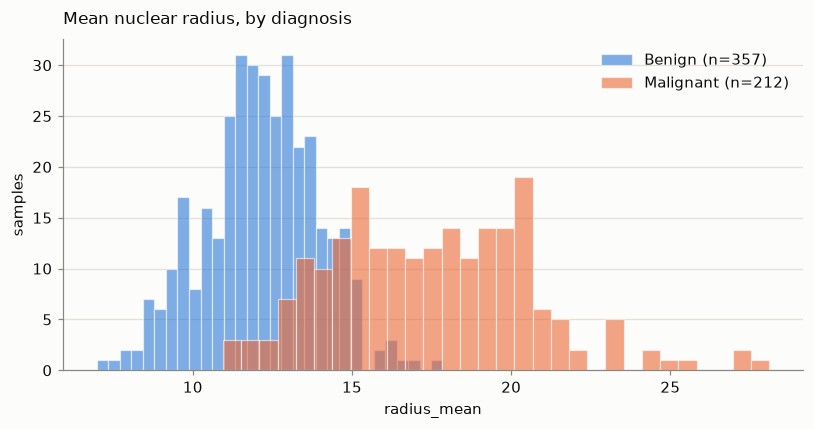

In [27]:
fig, ax = plt.subplots(figsize=(7.5, 4))

bins = 30
for label in ["B", "M"]:
    values = df.loc[df["diagnosis"] == label, "radius_mean"]
    ax.hist(values, bins=bins, alpha=0.6, color=CLASS_COLOUR[label],
            label=f"{CLASS_LABEL[label]} (n={len(values)})",
            edgecolor=SURFACE, linewidth=0.8)

ax.set_title("Mean nuclear radius, by diagnosis")
ax.set_xlabel("radius_mean")
ax.set_ylabel("samples")
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Two distributions, clearly shifted apart - and clearly overlapping in the middle. That overlap is the number we printed above, drawn. Every sample in the shared region is one that nuclear size alone cannot classify.

### Which measurements separate the classes best?

A box plot per feature, benign beside malignant. Box plots compress a distribution to its median, its middle 50%, and its outliers, which makes them good for comparing many features at once.

The four features are chosen to make a point: two describe **size**, one describes **shape**, and one describes almost nothing.

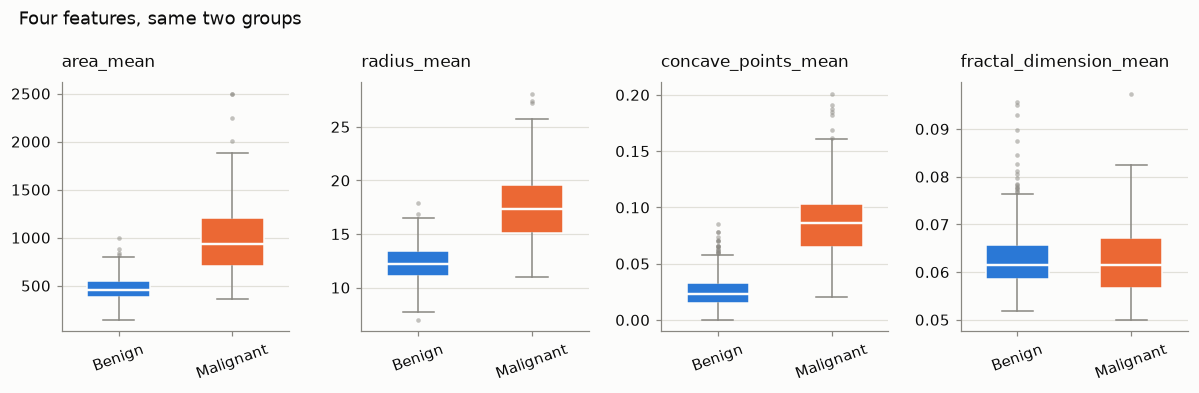

In [28]:
features = ["area_mean", "radius_mean", "concave_points_mean", "fractal_dimension_mean"]

fig, axes = plt.subplots(1, 4, figsize=(11, 3.6))

for ax, feature in zip(axes, features):
    data = [df.loc[df["diagnosis"] == label, feature] for label in ["B", "M"]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    tick_labels=["Benign", "Malignant"],
                    medianprops=dict(color=SURFACE, linewidth=1.6),
                    flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED,
                                    markeredgecolor="none", alpha=0.5))
    for patch, label in zip(bp["boxes"], ["B", "M"]):
        patch.set_facecolor(CLASS_COLOUR[label])
        patch.set_edgecolor(SURFACE)
    for part in ("whiskers", "caps"):
        for line in bp[part]:
            line.set_color(MUTED)

    ax.set_title(feature)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelrotation=20)

fig.suptitle("Four features, same two groups", x=0.02, ha="left", fontsize=12, color=INK)
plt.tight_layout()
plt.show()

Read left to right. `area_mean` and `radius_mean` do separate the groups - but look at the whiskers, which reach well into each other. Plenty of individual samples sit squarely inside the other group's range.

`concave_points_mean` gives the cleanest split of the four: the boxes are far apart *relative to their own spread*, which is the thing that actually matters. It is a shape feature, counting indentations in the nuclear outline - not a size feature.

And `fractal_dimension_mean` does not separate them at all. The two boxes sit on top of each other.

A feature that does not distinguish the classes is not a failure. It is information, and it is exactly what feature selection is for.

### Do two features do better than one?

Neither radius nor concave points separates the classes alone. Plot them against each other and see what happens in two dimensions.

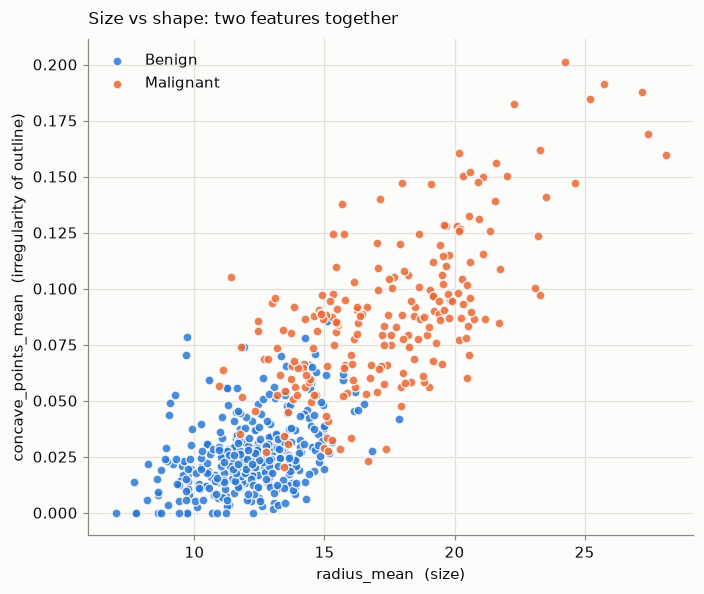

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for label in ["B", "M"]:
    subset = df[df["diagnosis"] == label]
    ax.scatter(subset["radius_mean"], subset["concave_points_mean"],
               s=34, color=CLASS_COLOUR[label], label=CLASS_LABEL[label],
               edgecolor=SURFACE, linewidth=0.9, alpha=0.85)

ax.set_title("Size vs shape: two features together")
ax.set_xlabel("radius_mean  (size)")
ax.set_ylabel("concave_points_mean  (irregularity of outline)")
ax.grid()
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

This is the picture that justifies the rest of the series.

Look along either axis alone and the two groups overlap. Look at the plane and they occupy visibly
different regions - you could almost draw a line between them by hand. Two mediocre features combine into something much better than either.

"Almost" is doing real work in that sentence. There is no line that gets every point right, and the points near the boundary are precisely the patients where the decision matters most.

### Which features are telling us the same thing?

Thirty features does not mean thirty independent pieces of information. A correlation matrix shows which ones move together.

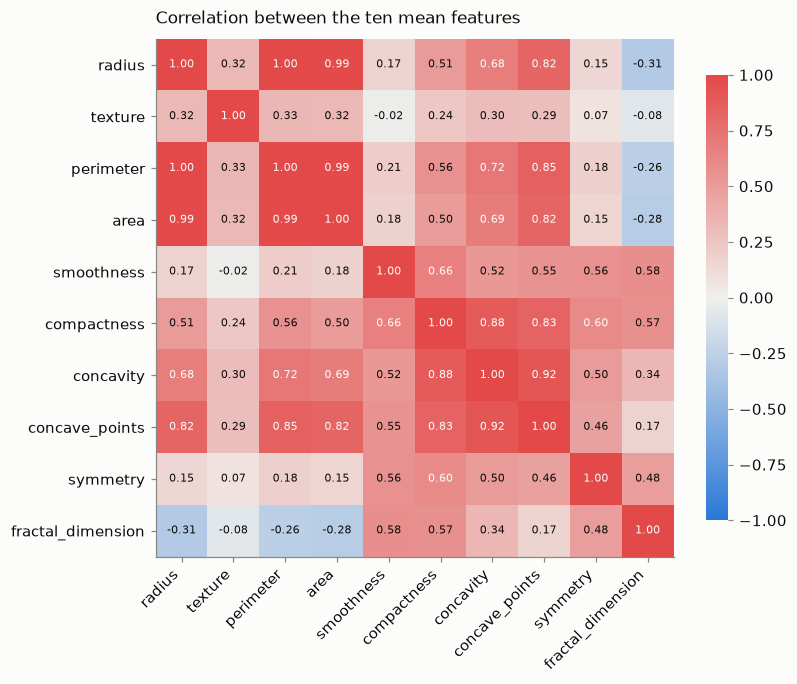

In [30]:
corr = df[mean_features].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.4))
im = ax.imshow(corr, cmap=CORR_CMAP, vmin=-1, vmax=1)

labels = [c.replace("_mean", "") for c in mean_features]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)

# The numbers matter as much as the colour, so print them.
for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                color=SURFACE if abs(value) >= 0.6 else INK)

ax.set_title("Correlation between the ten mean features")
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.outline.set_visible(False)
cbar.ax.tick_params(color=MUTED)

plt.tight_layout()
plt.show()

Look at the top-left block. `radius`, `perimeter` and `area` correlate at **0.99 and above** - they are, to three decimal places, the same measurement. Which makes sense: for a roughly circular shape, perimeter and area are both functions of the radius. Three columns, one piece of biology.

`concavity`, `concave_points` and `compactness` form a second cluster, all describing outline irregularity.

So the thirty columns are not thirty independent facts. They are a much smaller number of biological
properties, each measured several ways. That has real consequences for modelling - and it is the reason Article 3 asks whether we need all thirty features at all.

If you prefer the numbers to the picture, the same information as a table:

In [31]:
# Stack the matrix into one row per pair.
pairs = corr.stack()

# Each pair appears twice, (A,B) and (B,A), plus a 1.0 on the diagonal.
# Keeping only pairs where the first name sorts before the second drops both problems at once.
first = pairs.index.get_level_values(0)
second = pairs.index.get_level_values(1)
pairs = pairs[first < second]

top = pairs.abs().sort_values(ascending=False).head(8).index

pd.DataFrame({
    "feature_a": [a.replace("_mean", "") for a, _ in top],
    "feature_b": [b.replace("_mean", "") for _, b in top],
    "correlation": [round(corr.loc[a, b], 3) for a, b in top],
})

,feature_a,feature_b,correlation
0,perimeter,radius,0.998
1,area,radius,0.987
2,area,perimeter,0.987
3,concave_points,concavity,0.921
4,compactness,concavity,0.883
5,concave_points,perimeter,0.851
6,compactness,concave_points,0.831
7,area,concave_points,0.823


---
## What we have

Starting from a URL, we now have:

- the raw file on disk, alongside its documentation
- a shell-level understanding of what is in it: 569 rows, no header, comma-separated, 32 fields
- a DataFrame with correct column names and correct types, and no missing values
- confirmation that the biology is present in the numbers, and that **shape separates the classes better than size**
- a demonstration that no single measurement is enough, because the ranges overlap
- the knowledge that the thirty features contain far fewer than thirty independent facts

That last set of points is not a modelling result. It is a set of things we can *see*.

Seeing is not knowing. Every claim above came from looking at a picture, and a picture cannot tell you whether a difference is real or whether you are reading noise in 569 samples.

**Article 3** starts exactly there: is the difference real, how would we know, and what happens when we ask a model to make the decision for us.